# Using Adaptive Metrapolis-Hastings Markov Chain Monte Carlo
## For estimating $H_0$ and other parameters

In [30]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

c = 299792.458 

In [31]:
data = pd.read_csv("Pantheon Data/Pantheon_SNdata.csv") # To check the data, you can use: print(data.head())

---


In [32]:
#Defining Chi squared function

def chi_sq(obs, theo, err):
    obs= np.array(obs)
    theo=np.array(theo)
    err=np.array(err)
    chi_squared=np.sum(((obs-theo)/err)**2)
    return chi_squared

In [33]:
def plot_hist_with_gaussian(data, param_name, bins=50, color='#7F77DD', save_path=None):
    """Histogram of MCMC samples with a fitted Gaussian overlay."""
    data = np.asarray(data)
 
    # Fit a Gaussian: returns (mean, std) that best match the sample distribution
    mu, sigma = stats.norm.fit(data)
 
    fig, ax = plt.subplots(figsize=(6, 4))
 
    # density=True normalizes the histogram so its area = 1, matching the
    # Gaussian pdf's area, otherwise the curve and bars are on different scales
    counts, bin_edges, _ = ax.hist(data, bins=bins, density=True,
                                    color=color, alpha=0.6,
                                    edgecolor='white', linewidth=0.3,
                                    label='MCMC samples')
 
    x = np.linspace(data.min(), data.max(), 300)
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color='black', lw=2,
            label=f'Gaussian fit\n$\\mu$={mu:.7f}, $\\sigma$={sigma:.7f}')
 
    ax.axvline(mu, color='red', linestyle='--', lw=0.8)
 
    ax.set_xlabel(param_name)
    ax.set_ylabel('Probability density')
    ax.set_title(f'Posterior distribution: {param_name}')
    ax.legend()
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
 
    return mu, sigma

---

# Standard and Adaptive MH MCMC method to estimation of multi-parametered model 

#### First, we'll do standard method to get the covariance matrix

we do it for smaller # of iterations, to avoid time comsuming computation

In [34]:
def Hubble(z, H0, omega_m, w):
    return H0 * np.sqrt(omega_m * (1 + z)**3 + (1 - omega_m) * (1 + z)**(3 * (1 + w)))

def integrand(z, H0, omega_m, w):
    return c / Hubble(z, H0, omega_m, w)

def DISTANCE_MODULUS(z, H0, omega_m, w):
    D_c, error = integrate.quad(integrand, 0, z, args=(H0, omega_m, w))
    D_L = D_c * (1 + z)
    return 5*np.log10(D_L) + 25

def CALCULATE_NEW(omega_m_prev, H0_prev, w_prev,
                    domega_m, dH0, dw,
                    omega_m_range, H0_range, w_range):
    omega_m_new = omega_m_prev + domega_m * np.random.normal(0, 1)
    H0_new = H0_prev + dH0 * np.random.normal(0, 1)
    w_new = w_prev + dw * np.random.normal(0, 1)
    if (omega_m_range[0] <= omega_m_new <= omega_m_range[1]
        and H0_range[0] <= H0_new <= H0_range[1]
        and w_range[0] <= w_new <= w_range[1]):
        return omega_m_new, H0_new, w_new
    return CALCULATE_NEW(omega_m_prev, H0_prev, w_prev, domega_m, dH0, dw,
                         omega_m_range, H0_range, w_range)

In [35]:

# define some constants (parameters)
omega_m_range = [0.15, 0.45]
H0_range = [55, 85]
w_range = [-2.0, 0.0]
delta_w = 0.03
delta_omega_m = 0.005
delta_H0 = 0.2
print(f'\u03A9_m range:{omega_m_range}, \u0394\u03A9_m:{delta_omega_m},\nH0 range:{H0_range}, \u0394H0:{delta_H0},\nw range:{w_range}, \u0394w:{delta_w}')

N_iterations =4000 

Ω_m range:[0.15, 0.45], ΔΩ_m:0.005,
H0 range:[55, 85], ΔH0:0.2,
w range:[-2.0, 0.0], Δw:0.03


In [36]:
mcmc_df = pd.DataFrame(columns=['H0', 'Omega_m', 'w', 'Chi_sq', 'Type'])
 
omega_m_prev = np.random.uniform(*omega_m_range)
H0_prev = np.random.uniform(*H0_range)
w_prev = np.random.uniform(*w_range)
print(f'Initial values: Omega_m={omega_m_prev:.3f}, H0={H0_prev:.2f}, w={w_prev:.3f}')
 
chi_sq1 = chi_sq(data['dist_mod'],
                 [DISTANCE_MODULUS(z, H0_prev, omega_m_prev, w_prev) for z in data['zcmb']],
                 data['dmb'])
print("Chi_squared initial:", chi_sq1, '\n')
 
print("Begin MH-MCMC\n")
for nstep in range(N_iterations):
    omega_m_new, H0_new, w_new = CALCULATE_NEW(omega_m_prev, H0_prev, w_prev,
                                                delta_omega_m, delta_H0, delta_w,
                                                omega_m_range, H0_range, w_range)
    chi_sq2 = chi_sq(data['dist_mod'],
                     [DISTANCE_MODULUS(z, H0_new, omega_m_new, w_new) for z in data['zcmb']],
                     data['dmb'])
 
    if chi_sq2 <= chi_sq1:
        omega_m_prev, H0_prev, w_prev, chi_sq1 = omega_m_new, H0_new, w_new, chi_sq2
        type_val = 1
        mcmc_df.loc[len(mcmc_df)] = [H0_prev, omega_m_prev, w_prev, chi_sq1, type_val]
        print(f'{nstep}) -- type 1, omega_m: {omega_m_prev}, H0 = {H0_prev}, w = {w_prev}, chi_sq: {chi_sq1}')
    else:
        nrand = np.random.uniform(0, 1)
        prob_ratio = np.exp(-(chi_sq2 - chi_sq1) / 2)
        if prob_ratio > nrand:
            omega_m_prev, H0_prev, w_prev, chi_sq1 = omega_m_new, H0_new, w_new, chi_sq2
            type_val = 2
            mcmc_df.loc[len(mcmc_df)] = [H0_prev, omega_m_prev, w_prev, chi_sq1, type_val]
            print(f'{nstep}) -- type 2, omega_m: {omega_m_prev}, H0 = {H0_prev}, w = {w_prev}, chi_sq: {chi_sq1}')
        else:
            type_val = 3
 
print("\nomega_m_Final, H0_Final, w_Final:", omega_m_prev, H0_prev, w_prev)
print('Final Chi_sq value:', chi_sq1)

Initial values: Omega_m=0.230, H0=57.33, w=-1.238
Chi_squared initial: 16830.586929584813 

Begin MH-MCMC

3) -- type 1, omega_m: 0.24001843842233103, H0 = 57.02540328006126, w = -1.2055020516174488, chi_sq: 16689.48870920163
4) -- type 1, omega_m: 0.239067687128666, H0 = 57.35337685392159, w = -1.2316777359952367, chi_sq: 16338.83793291514
6) -- type 1, omega_m: 0.23849804637882596, H0 = 57.33504428499669, w = -1.1840014956358056, chi_sq: 15748.66797175812
9) -- type 1, omega_m: 0.24949179392514673, H0 = 57.78393487029179, w = -1.173951107862259, chi_sq: 14297.993980127854
15) -- type 1, omega_m: 0.24933038737162247, H0 = 57.800627020612175, w = -1.1343156059329351, chi_sq: 13773.367367986266
17) -- type 1, omega_m: 0.24363588457620933, H0 = 57.89239908365353, w = -1.1218144600566, chi_sq: 13595.32663991556
18) -- type 1, omega_m: 0.24875126691573304, H0 = 57.973185402251325, w = -1.0925567235988534, chi_sq: 12931.522070179537
22) -- type 1, omega_m: 0.25815053216567, H0 = 57.86537680

In [60]:
#Removing the Burnt-in Values
final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.01*final_chi_sq].index[0]
trimmed_df = mcmc_df.loc[first_valid_index:]

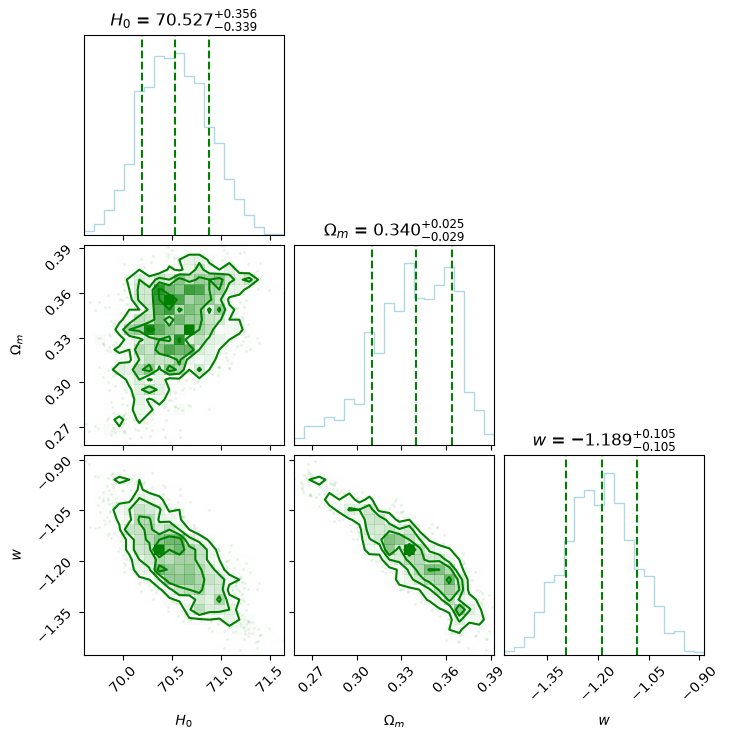

In [61]:
import corner

trimmed_df = mcmc_df.loc[first_valid_index:]
samples_w = trimmed_df[['H0', 'Omega_m', 'w']].to_numpy()
labels_w = ['$H_0$', '$\\Omega_m$', '$w$']

figure = corner.corner(samples_w, labels=labels_w, show_titles=True,
                       quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".3f", color='green', hist_kwargs={"color": "lightblue"})

figure.savefig('Saved Data/adap_pilot_corner.png', dpi=150, bbox_inches='tight')


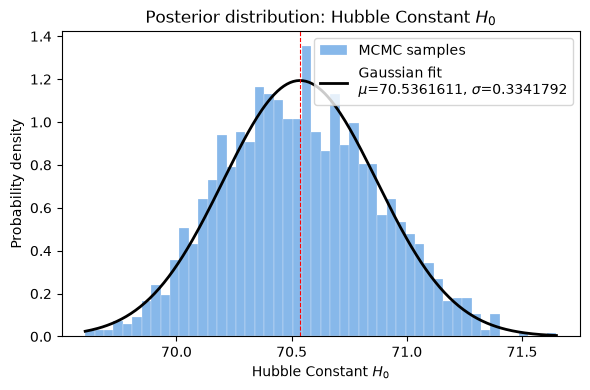

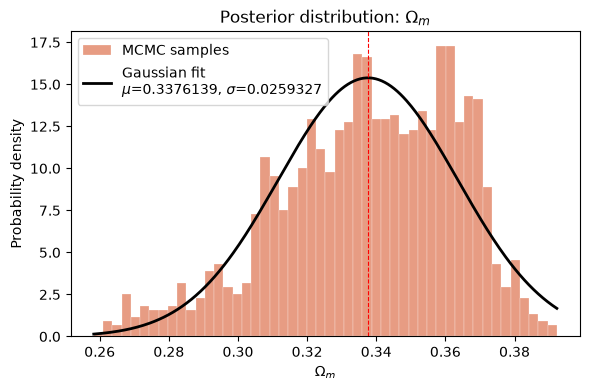

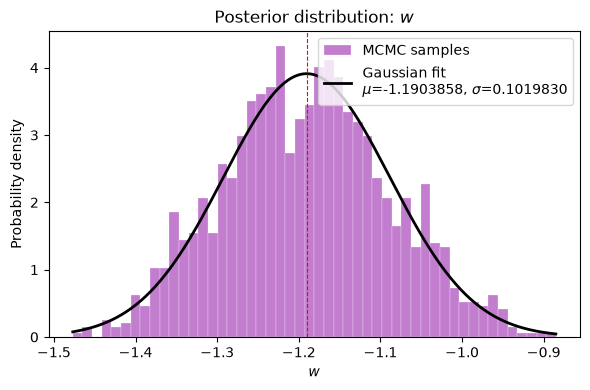

H0      = 70.54 +/- 0.33 km/s/Mpc
Omega_m = 0.338 +/- 0.026
w       = -1.190 +/- 0.102


In [62]:
H0_mean, H0_std = plot_hist_with_gaussian(trimmed_df['H0'], 'Hubble Constant $H_0$',
                                          color='#378ADD',
                                          save_path='Saved Data/adap_pilot_H0_posterior.png')
Om_mean, Om_std = plot_hist_with_gaussian(trimmed_df['Omega_m'], '$\\Omega_m$',
                                          color='#D85A30',
                                          save_path='Saved Data/adap_pilot_Omega_m_posterior.png')
w_mean, w_std = plot_hist_with_gaussian(trimmed_df['w'], '$w$',
                                        color='#9C27B0',
                                          save_path='Saved Data/adap_pilot_w_posterior.png')
 
print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"w       = {w_mean:.3f} +/- {w_std:.3f}")

# Adaptive MH MCMC for parameters H0, Omega_m and w

In [63]:
bounds = np.array([
    [55.0, 85.0],    # H0
    [0.15, 0.45],    # Omega_m
    [-2.0,  0.0],])  # w                   # bounds for the parameters

In [64]:
def in_bounds(theta):
    return np.all((bounds[:, 0] <= theta) & (theta <= bounds[:, 1])) # this function checks if the parameters are within the specified bounds
                                                                     # where theta is the array of parameters [H0, Omega_m, w]
def chi2_at(theta):
    H0, omega_m, w = theta
    theo = [DISTANCE_MODULUS(z, H0, omega_m, w) for z in data['zcmb']]
    return chi_sq(data['dist_mod'], theo, data['dmb']) #this function calculates the chi-squared value for a given set of parameters (H0, omega_m, w)

In [65]:
n_iter = 20000

prev = trimmed_df[['H0', 'Omega_m', 'w']].to_numpy()
cov = (2.38**2 / 3) * np.cov(prev.T)     # Roberts & Rosenthal optimal scaling = 2.38^2/d, where d is the number of parameters (3 in this case)
print("Proposal covariance from previous chain:\n", cov)

Proposal covariance from previous chain:
 [[ 0.2109873   0.00652921 -0.04718998]
 [ 0.00652921  0.00127056 -0.00439705]
 [-0.04718998 -0.00439705  0.01964955]]


In [ ]:
# --- plain Metropolis with that FIXED covariance ---
theta = np.array([H0_mean, Om_mean, w_mean])  # starting point for the MCMC chain
chi2_curr = chi2_at(theta)

chain = np.empty((n_iter, 3))
chi2_chain = np.empty(n_iter)
n_accepted = 0

for n in range(n_iter):
    theta_new = np.random.multivariate_normal(theta, cov)   # cov never changes
    if in_bounds(theta_new):
        chi2_new = chi2_at(theta_new)
        if chi2_new <= chi2_curr or np.exp(-(chi2_new - chi2_curr)/2) > np.random.uniform():
            theta, chi2_curr = theta_new, chi2_new
            n_accepted += 1
    chain[n] = theta
    chi2_chain[n] = chi2_curr

print(f"Acceptance rate: {n_accepted/n_iter:.1%}") # optimal acceptance rate for multivariate Gaussian proposals is ~23.4% (Roberts et al. 1997)
mcmc_pc = pd.DataFrame(chain, columns=['H0', 'Omega_m', 'w'])
mcmc_pc['Chi_sq'] = chi2_chain

Acceptance rate: 30.9%


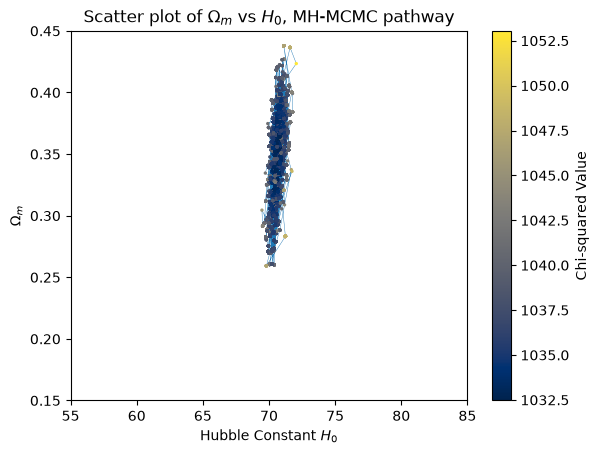

In [ ]:
# Scatter plot of Ω_m vs H_0 MH-MCMC pathway
plt.plot(mcmc_pc['H0'], mcmc_pc['Omega_m'], linewidth =0.3, zorder=1)
plt.scatter(mcmc_pc['H0'], mcmc_pc['Omega_m'], c=mcmc_pc['Chi_sq'], cmap='cividis', s = 2, zorder=2)
plt.colorbar(label='Chi-squared Value')
plt.xlabel('Hubble Constant $H_0$')
plt.ylabel('$\u03A9_m$')
plt.title('Scatter plot of $\u03A9_m$ vs $H_0$, MH-MCMC pathway')

plt.xlim(H0_range[0], H0_range[1])
plt.ylim(omega_m_range[0], omega_m_range[1])

plt.savefig('Saved Data/adap_wcdm_pathway.png', dpi=150, bbox_inches='tight')
plt.show()

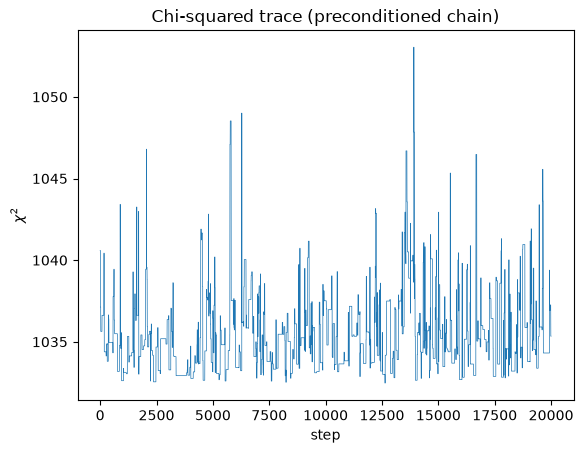

Discarded 118 burn-in rows, 1641 remain


In [66]:
# --- diagnostic trace + burn-in cut ---
plt.plot(mcmc_pc['Chi_sq'].values, lw=0.5)
plt.xlabel('step')
plt.ylabel(r'$\chi^2$')
plt.title('Chi-squared trace (preconditioned chain)')
plt.savefig('Saved Data/adap_wcdm_chi2_trace.png', dpi=150, bbox_inches='tight')
plt.show()

final_chi_sq = mcmc_df['Chi_sq'].iloc[-1]
first_valid_index = mcmc_df[mcmc_df['Chi_sq'] < 1.01*final_chi_sq].index[0]
print(f"Discarded {first_valid_index} burn-in rows, {len(mcmc_df) - first_valid_index} remain")

trimmed_pc = mcmc_pc.loc[first_valid_index:]

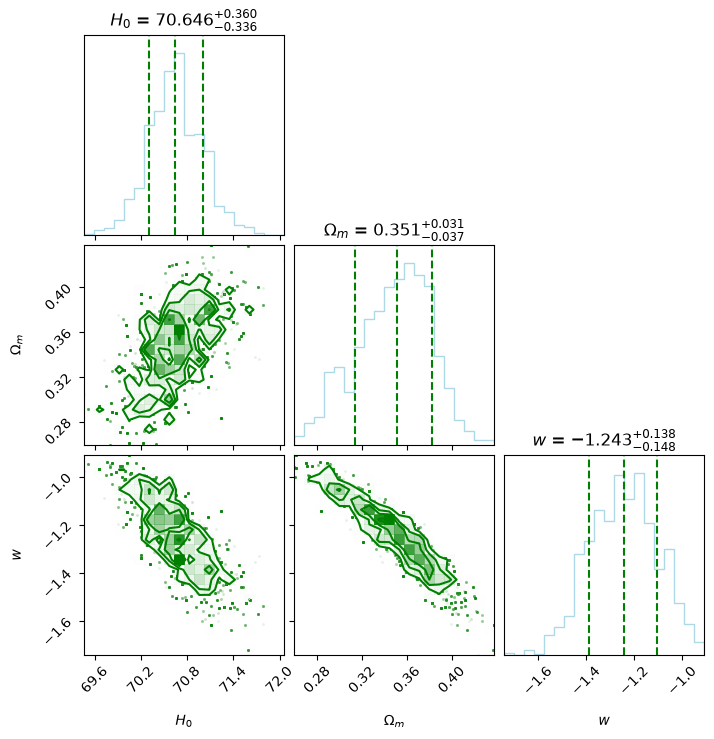

In [46]:

samples = mcmc_pc[['H0', 'Omega_m', 'w']].to_numpy()
labels = ['$H_0$', '$\\Omega_m$', '$w$']
figure = corner.corner(samples, labels=labels, show_titles=True,
                       quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12},
                       title_fmt=".3f", color='green', hist_kwargs={"color": "lightblue"})

figure.savefig('Saved Data/adap_wcdm_corner.png', dpi=150, bbox_inches='tight')


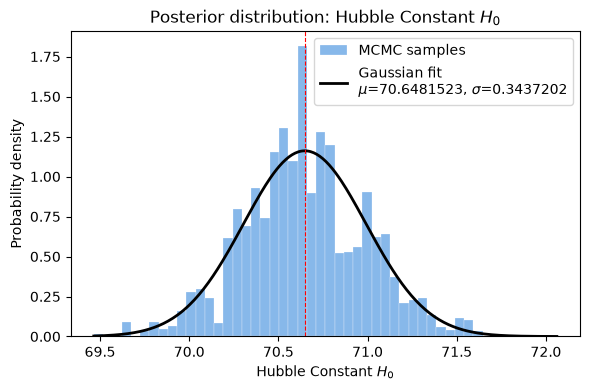

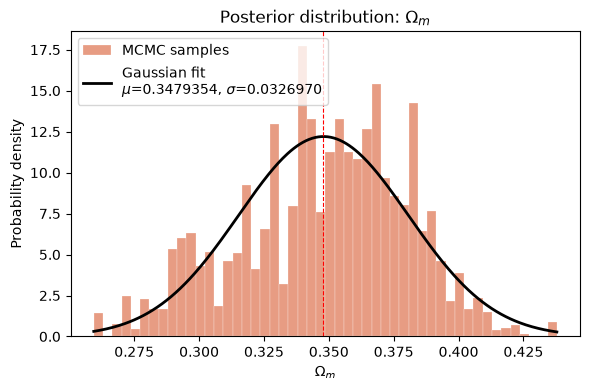

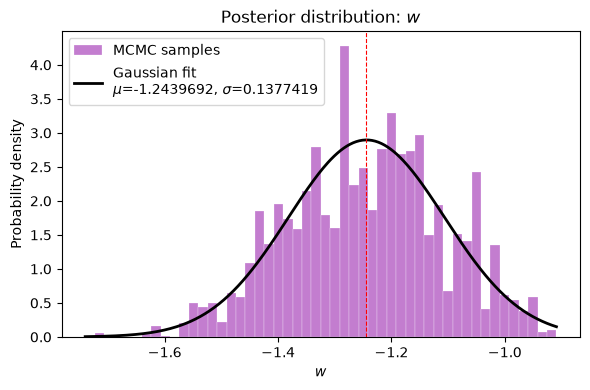

H0      = 70.65 +/- 0.34 km/s/Mpc
Omega_m = 0.348 +/- 0.033
w       = -1.244 +/- 0.138


In [47]:
# --- histograms + Gaussian fits ---
H0_mean, H0_std = plot_hist_with_gaussian(mcmc_pc['H0'], 'Hubble Constant $H_0$',
                                          color='#378ADD',
                                          save_path='Saved Data/adap_wcdm_H0_posterior.png')
Om_mean, Om_std = plot_hist_with_gaussian(mcmc_pc['Omega_m'], '$\\Omega_m$',
                                          color='#D85A30',
                                          save_path='Saved Data/adap_wcdm_Omega_m_posterior.png')
w_mean, w_std = plot_hist_with_gaussian(mcmc_pc['w'], '$w$',
                                        color='#9C27B0',
                                          save_path='Saved Data/adap_wcdm_w_posterior.png')

print(f"H0      = {H0_mean:.2f} +/- {H0_std:.2f} km/s/Mpc")
print(f"Omega_m = {Om_mean:.3f} +/- {Om_std:.3f}")
print(f"w       = {w_mean:.3f} +/- {w_std:.3f}")

---
# Conclusion

## Why wCDM is hard to sample

With $w$ free the expansion history becomes

$$H^2(z) = H_0^2\left[\Omega_m (1+z)^3 + (1-\Omega_m)(1+z)^{3(1+w)}\right]$$

and $w$ enters $\mu(z)$ almost the same way a shift in $H_0$ and $\Omega_m$ does.
The posterior is then a long curved ridge rather than a compact blob, and four
things go wrong at once:

1. **Correlation.** An isotropic proposal small enough to be accepted *across* the
   ridge is too small to move *along* it. Hence the pilot run plus fixed covariance
   used here.
2. **Dimension.** For a $d$-dimensional Gaussian target the optimal proposal scale
   is $\propto 2.38/\sqrt{d}$ with acceptance $\to 0.234$. Each extra parameter
   shortens the usable step.
3. **Curvature.** The covariance is one global Gaussian approximation, but the
   $H_0$-$w$ degeneracy is banana shaped, so a proposal tuned mid-ridge is wrong at
   both ends. Fixing this needs `emcee` or HMC.
4. **Cost.** Every $\chi^2$ integrates $D_C$ for ~1000 supernovae.

The symptom is in the error bars. Adding $w$ to the CMB fit inflates $\sigma_{H_0}$
from $1.86$ to $10.82$:

$$\frac{\sigma_{H_0}^{w\rm CDM}}{\sigma_{H_0}^{\Lambda\rm CDM}} \approx 5.8$$

## SNe vs CMB

| Parameter | SNe ($\Lambda$CDM) | CMB ($\Lambda$CDM) |
|---|---|---|
| $H_0$ | $70.18 \pm 0.22$ | $64.96 \pm 1.86$ |
| $\Omega_m$ | $0.284 \pm 0.012$ | $0.339$ (derived) |
| $\Omega_b h^2$ | | $0.02117 \pm 0.00037$ |
| $\Omega_c h^2$ | | $0.1218 \pm 0.0038$ |
| $n_s$ | | $0.9489 \pm 0.0119$ |

| Parameter | SNe (wCDM) | CMB (wCDM) |
|---|---|---|
| $H_0$ | $70.45 \pm 0.28$ | $71.31 \pm 10.82$ |
| $w$ | $-1.134 \pm 0.074$ | $-1.207 \pm 0.380$ |

Three points:

**They disagree on $H_0$ by $5.22$ km/s/Mpc ($2.8\sigma$), with the CMB low.** Same
direction as the published $73.0$ vs $67.4$.

**They constrain different things.** SNe say nothing about $\Omega_b h^2$, $\Omega_c h^2$
or $n_s$, which come from the acoustic peak shape. The CMB constrains $w$ five times
more weakly ($\pm 0.38$ vs $\pm 0.074$), since it only sees dark energy through the
distance to last scattering. Real analyses combine them for this reason.

**Both are consistent with $w = -1$** at $1.8\sigma$ and $0.5\sigma$. The extra
parameter buys nothing.

## Caveats

* Errors are chain standard deviations, so autocorrelation is ignored and they run
  optimistic, worst for the wCDM runs.
* $M_B$ is held fixed. For SNe alone $M_B$ and $H_0$ are perfectly degenerate, so
  $\pm 0.22$ assumes the calibration rather than measuring it. Supplying it is the
  job of `Cepheid Variables/`.
* The CMB $H_0$ is itself below Planck's $67.4$, from the approximate mask
  correction discussed in `CMB/CMB_MCMC_adaptive.ipynb`.